# Inspect Dataset

## Import Packages

In [1]:
%matplotlib inline

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from seaborn_qqplot import pplot
import numpy as np
from ydata_profiling import ProfileReport

In [3]:
from scipy import stats

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler,
    Normalizer,
    QuantileTransformer,
    MinMaxScaler,
    KBinsDiscretizer,
    PolynomialFeatures,
    FunctionTransformer,
    PowerTransformer
)
from sklearn.impute import SimpleImputer

## File Directories

In [7]:
INPUT_DIR = os.path.join("../input")

In [8]:
OUTPUT_DIR = os.path.join("../output")

In [9]:
TEMP_DIR = os.path.join("../temp")

In [10]:
FILE_DIR = os.path.join("../input/global-superstore.xls")

## Load Data

In [19]:
superstore_df = pd.read_excel(os.path.join(FILE_DIR))

In [20]:
return_superstore_df = pd.read_excel(os.path.join(FILE_DIR), sheet_name=1)

In [21]:
return_superstore_df.dtypes

Returned    object
Order ID    object
Market      object
dtype: object

**NOTE:**

---

Prüfen, ob die `ORDER ID` aus der Retouren-Tabelle mit denen aus der Verkaufs-Tabelle übereinstimmen.

**Resultat**:

Die `Order IDs` aus der Retouren-Tabelle stimmen mit denen aus der Verkaufs-Tabelle überein.

---

In [33]:
orderid_return_set = set(return_superstore_df["Order ID"])

orderid_match = [
    oid for oid in superstore_df["Order ID"]
    if oid in orderid_return_set
]

## EDA

### Superstore Verkaufs-Tabelle

In [26]:
superstore_df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country',
       'Postal Code', 'Market', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit', 'Shipping Cost', 'Order Priority'],
      dtype='object')

In [28]:
num_var = ["Discount", "Quantity", "order_to_ship_date"]
cat_var = ["Category", "Sub-Category", "Market"]

In [356]:
superstore_df.shape

(51290, 24)

In [90]:
superstore_df.dtypes

Row ID                     int64
Order ID                  object
Order Date        datetime64[ns]
Ship Date         datetime64[ns]
Ship Mode                 object
Customer ID               object
Customer Name             object
Segment                   object
City                      object
State                     object
Country                   object
Postal Code              float64
Market                    object
Region                    object
Product ID                object
Category                  object
Sub-Category              object
Product Name              object
Sales                    float64
Quantity                   int64
Discount                 float64
Profit                   float64
Shipping Cost            float64
Order Priority            object
dtype: object

In [92]:
print(superstore_df.isnull().sum())

Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
City                  0
State                 0
Country               0
Postal Code       41296
Market                0
Region                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Profit                0
Shipping Cost         0
Order Priority        0
dtype: int64


In [183]:
print(superstore_df.describe(include="all"))

             Row ID        Order ID                     Order Date  \
count   51290.00000           51290                          51290   
unique          NaN           25035                            NaN   
top             NaN  CA-2014-100111                            NaN   
freq            NaN              14                            NaN   
mean    25645.50000             NaN  2013-05-11 21:26:49.155781120   
min         1.00000             NaN            2011-01-01 00:00:00   
25%     12823.25000             NaN            2012-06-19 00:00:00   
50%     25645.50000             NaN            2013-07-08 00:00:00   
75%     38467.75000             NaN            2014-05-22 00:00:00   
max     51290.00000             NaN            2014-12-31 00:00:00   
std     14806.29199             NaN                            NaN   

                            Ship Date       Ship Mode Customer ID  \
count                           51290           51290       51290   
unique               

### Superstore Retouren-Tabelle

In [270]:
return_superstore_df.columns

Index(['Returned', 'Order ID', 'Market'], dtype='object')

In [267]:
return_superstore_df.shape

(1173, 3)

In [272]:
print(return_superstore_df.isnull().sum())

Returned    0
Order ID    0
Market      0
dtype: int64


In [274]:
print(return_superstore_df.describe(include="all"))

       Returned        Order ID Market
count      1173            1173   1173
unique        1            1172      4
top         Yes  US-2014-136679  LATAM
freq       1173               2    297


### Merged: Verkaufs- und Retouren-Tabelle

In [665]:
merged_superstore_df.describe(include="all")

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Returned
count,51295.000000,51295,51295,51295,51295,51295,51295,51295,51295,51295,...,51295,51295,51295,51295.000000,51295.000000,51295.000000,51295.000000,51295.000000,51295,51295
unique,NaN,25035,NaN,NaN,4,1590,795,3,3636,1094,...,3,17,3788,NaN,NaN,NaN,NaN,NaN,4,2
top,NaN,CA-2014-100111,NaN,NaN,Standard Class,PO-18850,Muhammed Yedwab,Consumer,New York City,California,...,Office Supplies,Binders,Staples,NaN,NaN,NaN,NaN,NaN,Medium,No
freq,NaN,14,NaN,NaN,30780,97,108,26520,915,2001,...,31275,6152,227,NaN,NaN,NaN,NaN,NaN,29438,48240
mean,25644.896598,NaN,2013-05-11 22:30:30.213471232,2013-05-15 21:46:24.060824576,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,246.481137,3.476518,0.142905,28.610120,26.374248,NaN,NaN
min,1.000000,NaN,2011-01-01 00:00:00,2011-01-03 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.444000,1.000000,0.000000,-6599.978000,0.002000,NaN,NaN
25%,12821.500000,NaN,2012-06-19 00:00:00,2012-06-23 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,30.761250,2.000000,0.000000,0.000000,2.610000,NaN,NaN
50%,25645.000000,NaN,2013-07-08 00:00:00,2013-07-12 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,85.056000,3.000000,0.000000,9.240000,7.790000,NaN,NaN
75%,38466.500000,NaN,2014-05-22 00:00:00,2014-05-26 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,251.038800,5.000000,0.200000,36.810000,24.450000,NaN,NaN
max,51290.000000,NaN,2014-12-31 00:00:00,2015-01-07 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,22638.480000,14.000000,0.850000,8399.976000,933.570000,NaN,NaN


#### Pandas Profile Report

In [412]:
merged_superstore_profiling = ProfileReport(merged_superstore_df, title = "merged_superstore_profiling")

In [414]:
merged_superstore_profiling.to_file(os.path.join(OUTPUT_DIR, "merged_superstore_profiling.htlm"))

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

/opt/anaconda3/lib/python3.12/site-packages/ydata_profiling/model/typeset_relations.py:34: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pdt.is_categorical_dtype(series):


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

/opt/anaconda3/lib/python3.12/site-packages/ydata_profiling/profile_report.py:384: UserWarning: Extension .htlm not supported. For now we assume .html was intended. To remove this warning, please use .html or .json.
  warnings.warn(


Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

**`Profit`**

### Korrelationsanalyse

In [115]:
corr_var = merged_returned_quantity_discount_osd_category_sub_market_df.columns[1:]

In [117]:
merged_returned_quantity_discount_osd_category_sub_market_df[corr_var].corr()

,num_returned,Quantity,Discount,order_to_ship_date,Furniture,Office Supplies,Technology,Accessories,Appliances,Art,...,Africa,Canada,EMEA,EU,LATAM,US,Order ID,artikel_pro_bestellung_mean,anzahl_an_kunden,quantity_per_cutstomer
num_returned,1.000000,0.269233,-0.050033,-0.044015,0.084850,0.142566,0.042802,0.037815,0.008153,0.037878,...,-0.137443,-0.056358,-0.138129,0.085385,0.171212,0.150857,0.247700,0.079335,0.246778,0.071920
Quantity,0.269233,1.000000,-0.094687,-0.069489,0.169842,0.582671,0.098671,0.080963,-0.021987,0.278758,...,-0.003478,0.011637,0.003037,0.392482,0.271419,0.285938,0.847239,0.013734,0.846126,0.425998
Discount,-0.050033,-0.094687,1.000000,0.005647,0.038704,-0.072759,-0.046070,-0.037470,-0.002538,-0.056040,...,0.019026,-0.034043,0.053826,-0.097331,-0.049262,0.007282,-0.087547,-0.003883,-0.087860,-0.030743
order_to_ship_date,-0.044015,-0.069489,0.005647,1.000000,0.003223,-0.063411,-0.029403,-0.031292,-0.011958,-0.016305,...,-0.038615,-0.012058,-0.034789,-0.007151,-0.020271,-0.037093,-0.089933,0.003055,-0.090039,0.021017
Furniture,0.084850,0.169842,0.038704,0.003223,1.000000,-0.327632,-0.189022,-0.094627,-0.083070,-0.093361,...,-0.034427,-0.017856,-0.036909,-0.025740,0.120447,0.107780,0.172482,-0.001099,0.171791,0.014618
Office Supplies,0.142566,0.582671,-0.072759,-0.063411,-0.327632,1.000000,-0.350287,-0.175358,0.074909,0.417226,...,0.230758,0.124729,0.237755,0.343590,0.114125,0.147665,0.701010,0.009599,0.699415,-0.001525
Technology,0.042802,0.098671,-0.046070,-0.029403,-0.189022,-0.350287,1.000000,0.530475,-0.088814,-0.099816,...,0.008262,-0.005697,0.013431,0.011726,0.057346,0.035616,0.120470,-0.001564,0.122009,-0.011224
Accessories,0.037815,0.080963,-0.037470,-0.031292,-0.094627,-0.175358,0.530475,1.000000,-0.044461,-0.049969,...,-0.021125,-0.010093,-0.011401,-0.023393,0.037266,0.086236,0.079870,-0.004879,0.080268,0.014002
Appliances,0.008153,-0.021987,-0.002538,-0.011958,-0.083070,0.074909,-0.088814,-0.044461,1.000000,-0.043867,...,-0.014496,0.002536,-0.022352,-0.021569,-0.025251,0.052121,-0.028150,0.013434,-0.028212,0.001256
Art,0.037878,0.278758,-0.056040,-0.016305,-0.093361,0.417226,-0.099816,-0.049969,-0.043867,1.000000,...,0.168730,0.089789,0.160964,0.282710,-0.011946,0.020019,0.351205,0.004339,0.349674,-0.013071


### Target Verteilung

#### `retouren_quote`

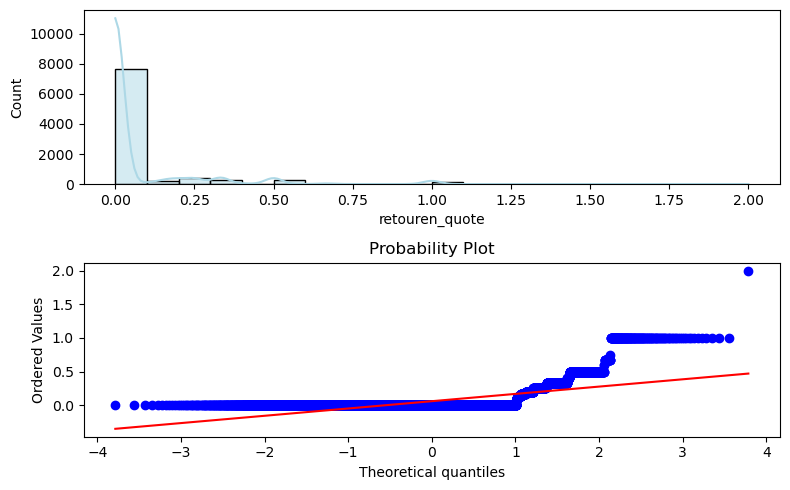

In [386]:
fig, ax = plt.subplots(2, 1, figsize=(8, 5))

sns.histplot(merged_returned_quantity_discount_osd_category_sub_market_df["retouren_quote"], ax=ax[0], color="lightblue" , bins=20, kde=True)
stats.probplot(merged_returned_quantity_discount_osd_category_sub_market_df["retouren_quote"], dist="norm", plot=ax[1])

plt.tight_layout()

### Cat_Features Verteilung

#### `Category`

In [102]:
cat_var = ["Category", "Sub-Category", "Market"]

<Axes: xlabel='Category'>

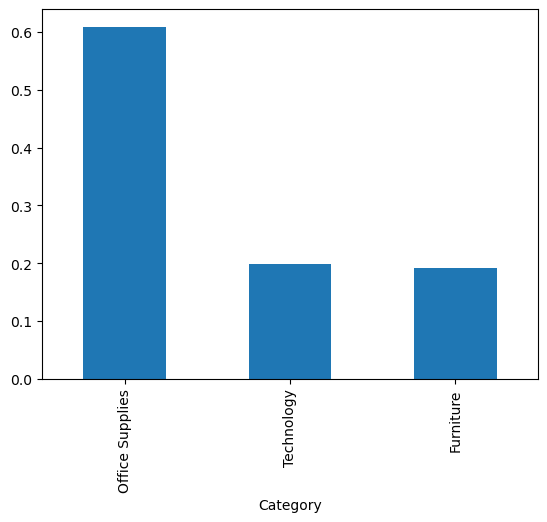

In [104]:
category_value_counts = merged_superstore_df["Category"].value_counts(normalize=True)
category_value_counts.plot.bar()

#### `Sub-Category`

<Axes: xlabel='Sub-Category'>

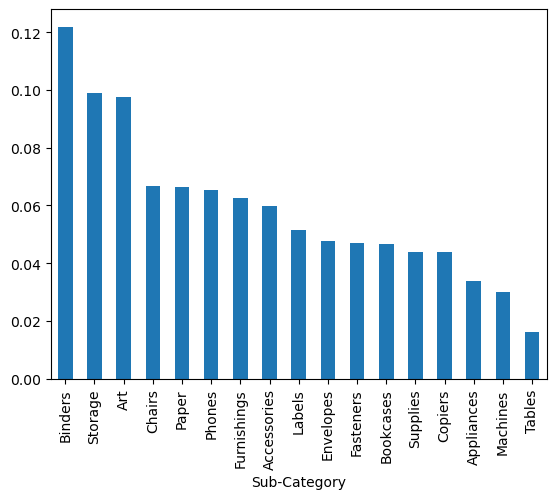

In [107]:
sub_category_value_counts = merged_superstore_df["Sub-Category"].value_counts(normalize=True)
sub_category_value_counts.plot.bar()

#### `Market`

<Axes: xlabel='Market'>

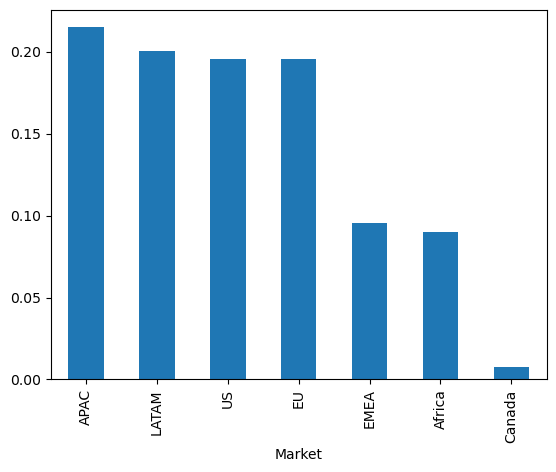

In [110]:
market_value_counts = merged_superstore_df["Market"].value_counts(normalize=True)
market_value_counts.plot.bar()

### Num_Feature Verteilung

In [123]:
num_var = ["Discount", "Quantity", "order_to_ship_date"]

In [125]:
print(merged_superstore_df[num_var].describe(include="all"))

           Discount      Quantity  order_to_ship_date
count  26520.000000  26520.000000        26520.000000
mean       0.143606      3.475302            3.953695
std        0.212487      2.268987            1.738745
min        0.000000      1.000000            0.000000
25%        0.000000      2.000000            3.000000
50%        0.000000      3.000000            4.000000
75%        0.200000      5.000000            5.000000
max        0.800000     14.000000            7.000000


#### `Discount`

In [227]:
df_with_discount = merged_returned_quantity_discount_osd_category_sub_market_df[merged_returned_quantity_discount_osd_category_sub_market_df["Discount"] > 0]

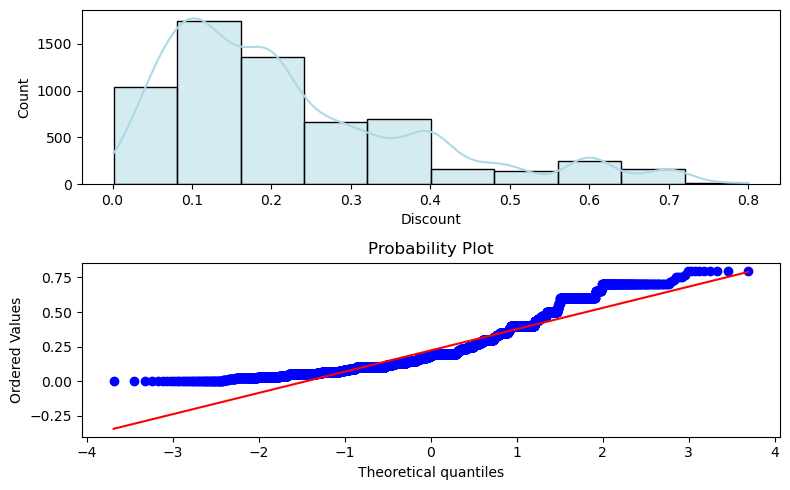

In [229]:
fig, ax = plt.subplots(2, 1, figsize=(8, 5))


sns.histplot(df_with_discount["Discount"], ax=ax[0], color="lightblue" , bins=10, kde=True)
stats.probplot(df_with_discount["Discount"], dist="norm", plot=ax[1])

plt.tight_layout()

#### `Quantity`

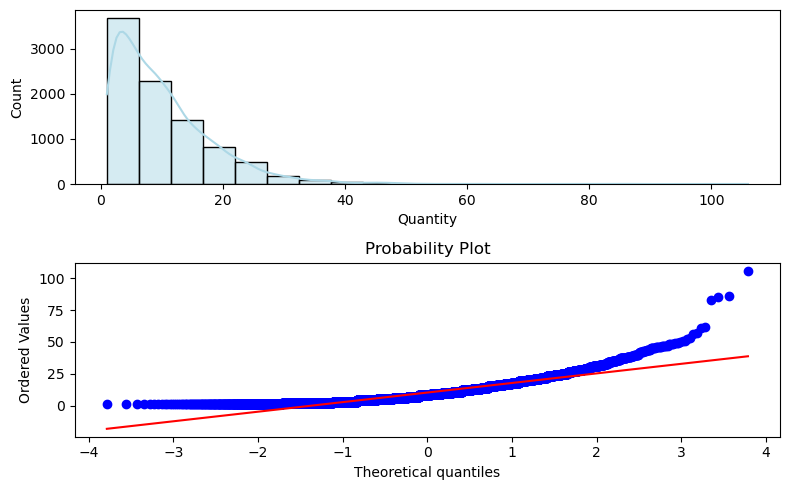

In [414]:
fig, ax = plt.subplots(2, 1, figsize=(8, 5))

sns.histplot(merged_returned_quantity_discount_osd_category_sub_market_df["Quantity"], ax=ax[0], color="lightblue" , bins=20, kde=True)
stats.probplot(merged_returned_quantity_discount_osd_category_sub_market_df["Quantity"], dist="norm", plot=ax[1])

plt.tight_layout()

#### `order_to_ship_date`

$$\chi^2 = \sum \frac{(Beobachtet - Erwartet)^2}{Erwartet}$$

In [130]:
order_to_ship_date.dtypes

order_to_ship_date    timedelta64[ns]
dtype: object

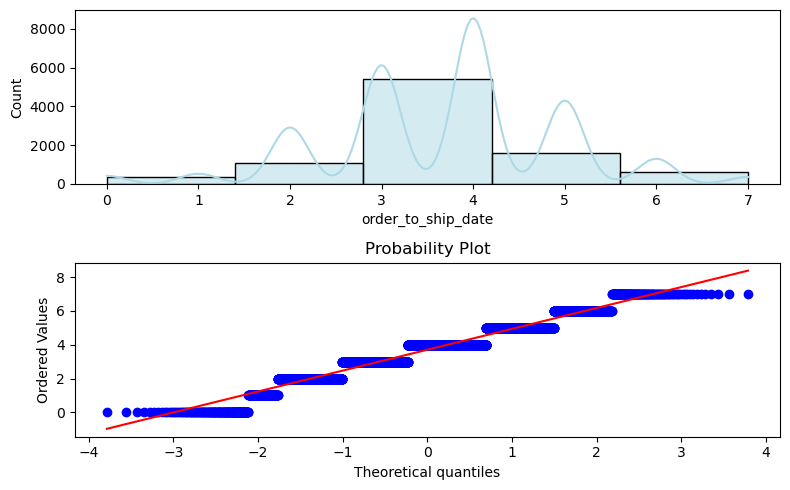

In [233]:
fig, ax = plt.subplots(2, 1, figsize=(8, 5))

sns.histplot(merged_returned_quantity_discount_osd_category_sub_market_df["order_to_ship_date"], ax=ax[0], color="lightblue" , bins=5, kde=True)
stats.probplot(merged_returned_quantity_discount_osd_category_sub_market_df["order_to_ship_date"], dist="norm", plot=ax[1])

plt.tight_layout()

#### `artikel_pro_bestellung_mean`

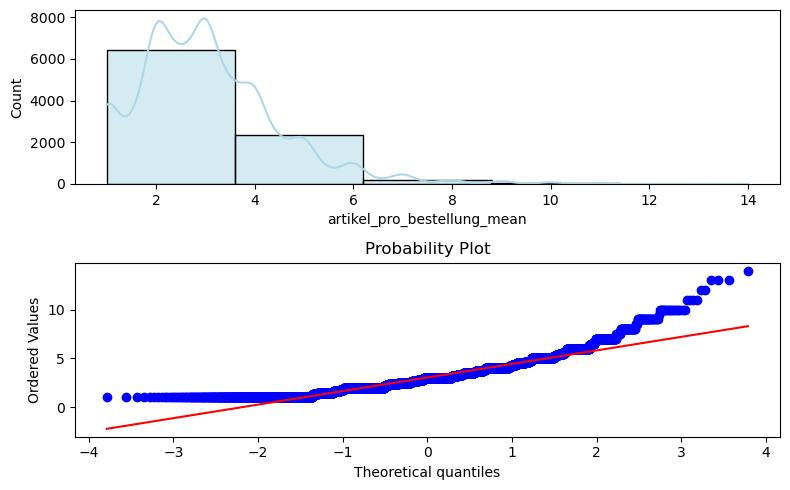

In [134]:
fig, ax = plt.subplots(2, 1, figsize=(8, 5))

sns.histplot(merged_returned_quantity_discount_osd_category_sub_market_df["artikel_pro_bestellung_mean"], ax=ax[0], color="lightblue" , bins=5, kde=True)
stats.probplot(merged_returned_quantity_discount_osd_category_sub_market_df["artikel_pro_bestellung_mean"], dist="norm", plot=ax[1])

plt.tight_layout()

## Transform

In [362]:
merged_returned_quantity_discount_osd_category_sub_market_df["retouren_quote"] = merged_returned_quantity_discount_osd_category_sub_market_df["num_returned"]/merged_returned_quantity_discount_osd_category_sub_market_df["Order ID"]
merged_returned_quantity_discount_osd_category_sub_market_df

,Product ID,num_returned,Quantity,Discount,order_to_ship_date,Furniture,Office Supplies,Technology,Accessories,Appliances,...,Tables,APAC,Africa,Canada,EMEA,EU,LATAM,US,Order ID,retouren_quote
0,FUR-ADV-10000108,0,1,0.00,7,1,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0.0
1,FUR-ADV-10000183,0,9,0.00,3,4,0,0,0,0,...,0,0,2,0,2,0,0,0,4,0.0
2,FUR-ADV-10000188,0,3,0.35,4,2,0,0,0,0,...,0,0,1,0,1,0,0,0,2,0.0
3,FUR-ADV-10000190,0,2,0.00,0,1,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0.0
4,FUR-ADV-10000571,0,13,0.00,4,4,0,0,0,0,...,0,0,1,0,3,0,0,0,4,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9042,TEC-STA-10004181,0,10,0.12,4,0,0,5,0,0,...,0,0,2,1,2,0,0,0,5,0.0
9043,TEC-STA-10004536,0,2,0.00,4,0,0,2,0,0,...,0,0,2,0,0,0,0,0,2,0.0
9044,TEC-STA-10004542,0,2,0.00,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,1,0.0
9045,TEC-STA-10004834,0,5,0.65,5,0,0,2,0,0,...,0,0,1,0,1,0,0,0,2,0.0


### Allgemeine Transformationen

In [44]:
merged_superstore_df["Returned"].value_counts()

Returned
No     48240
Yes     3055
Name: count, dtype: int64

In [25]:
merged_superstore_df = superstore_df.merge(return_superstore_df[["Order ID","Returned"]],how ="left", on="Order ID")

In [32]:
merged_superstore_df["Returned"]=merged_superstore_df["Returned"].fillna("No")

In [29]:
merged_superstore_df = merged_superstore_df[merged_superstore_df['Segment'] == "Consumer"]

### Num_Features

#### `Quantity`

**Piviot:** `Quantity` nach `Product ID` gruppieren

In [31]:
pivot_mean_quantity = merged_superstore_df.pivot_table( values= ["Quantity"], index = "Product ID", aggfunc="sum")
pivot_mean_quantity = pivot_mean_quantity.reset_index()
pivot_mean_quantity = pivot_mean_quantity.rename(columns={0: "Product ID"})
pivot_mean_quantity = pivot_mean_quantity.rename(columns={1: "Quantity"})
pivot_mean_quantity

,Product ID,Quantity
0,FUR-ADV-10000108,1
1,FUR-ADV-10000183,9
2,FUR-ADV-10000188,3
3,FUR-ADV-10000190,2
4,FUR-ADV-10000571,13
...,...,...
9042,TEC-STA-10004181,10
9043,TEC-STA-10004536,2
9044,TEC-STA-10004542,2
9045,TEC-STA-10004834,5


In [39]:
merged_returned_quantity_df = pivot_count_return.merge(pivot_mean_quantity[["Product ID","Quantity"]],how ="left", on="Product ID")
merged_returned_quantity_df

,Product ID,num_returned,Quantity
0,FUR-ADV-10000108,0,1
1,FUR-ADV-10000183,0,9
2,FUR-ADV-10000188,0,3
3,FUR-ADV-10000190,0,2
4,FUR-ADV-10000571,0,13
...,...,...,...
9042,TEC-STA-10004181,0,10
9043,TEC-STA-10004536,0,2
9044,TEC-STA-10004542,0,2
9045,TEC-STA-10004834,0,5


**Transformation der Variable `Quantity`**

In [48]:
#Einen Array für die Variable Sales erzeugen
quantity = merged_superstore_df.loc[:,["Quantity"]]

In [78]:
#Den index zurücksetzen
quantity = quantity.reset_index(drop=True)

In [61]:
# Anwendung der Potenzfunktion zur Eliminierung von schiefer Verteilung und Erzwingung der symmetrischen Glockenkurve.
pt = PowerTransformer(method='yeo-johnson')
quantity_ptransformed = pt.fit_transform(quantity)

In [63]:
# Die Array-Serie zu einem DataFrame umwandeln
quantity_ptransformed = pd.DataFrame(quantity_ptransformed)

In [65]:
#Den index zurücksetzen
quantity_ptransformed = quantity_ptransformed.reset_index(drop=True)

In [67]:
# Spalte umbenennen
quantity_ptransformed = quantity_ptransformed.rename(columns={0: "Quantity"})

#### `Discount`

**Piviot:** `Quantity` nach `Discount` gruppieren

In [41]:
pivot_mean_discount = merged_superstore_df.pivot_table( values= ["Discount"], index = "Product ID", aggfunc="mean")
pivot_mean_discount = pivot_mean_discount.reset_index()
pivot_mean_discount = pivot_mean_discount.rename(columns={0: "Product ID"})
pivot_mean_discount = pivot_mean_discount.rename(columns={1: "Discount"})
pivot_mean_discount

,Product ID,Discount
0,FUR-ADV-10000108,0.00
1,FUR-ADV-10000183,0.00
2,FUR-ADV-10000188,0.35
3,FUR-ADV-10000190,0.00
4,FUR-ADV-10000571,0.00
...,...,...
9042,TEC-STA-10004181,0.12
9043,TEC-STA-10004536,0.00
9044,TEC-STA-10004542,0.00
9045,TEC-STA-10004834,0.65


In [43]:
merged_returned_quantity_discount_df = merged_returned_quantity_df.merge(pivot_mean_discount[["Product ID","Discount"]],how ="left", on="Product ID")
merged_returned_quantity_discount_df

,Product ID,num_returned,Quantity,Discount
0,FUR-ADV-10000108,0,1,0.00
1,FUR-ADV-10000183,0,9,0.00
2,FUR-ADV-10000188,0,3,0.35
3,FUR-ADV-10000190,0,2,0.00
4,FUR-ADV-10000571,0,13,0.00
...,...,...,...,...
9042,TEC-STA-10004181,0,10,0.12
9043,TEC-STA-10004536,0,2,0.00
9044,TEC-STA-10004542,0,2,0.00
9045,TEC-STA-10004834,0,5,0.65


**QuantileTransformer**

In [80]:
qt = QuantileTransformer(n_quantiles=1000, output_distribution='normal', random_state=0)
discount_qtrans = qt.fit_transform(discount)
discount_qtrans

array([[-1.17689044],
       [ 0.3031681 ],
       [-0.29922973],
       ...,
       [-0.29922973],
       [ 1.59769842],
       [ 5.19933758]])

In [82]:
# Die Array-Serie zu einem DataFrame umwandeln
discount_qtrans = pd.DataFrame(discount_qtrans)
discount_qtrans

,0
0,-1.176890
1,0.303168
2,-0.299230
3,-0.299230
4,-1.176890
...,...
11596,0.764710
11597,5.199338
11598,-0.299230
11599,1.597698


In [84]:
# Spalte umbenennen
discount_qtrans = discount_qtrans.rename(columns={0: 'Discount'})
discount_qtrans

,Discount
0,-1.176890
1,0.303168
2,-0.299230
3,-0.299230
4,-1.176890
...,...
11596,0.764710
11597,5.199338
11598,-0.299230
11599,1.597698


**Filter out Zero Values**

In [69]:
discount_nonzeros = merged_superstore_df[merged_superstore_df['Discount'] != 0]

In [42]:
discount_nonzeros

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Returned
1,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.765,923.63,Critical,Yes
2,25330,IN-2013-71249,2013-10-17,2013-10-18,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.971,915.49,Medium,No
3,13524,ES-2013-1579342,2013-01-28,2013-01-30,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.540,910.16,Medium,No
5,22732,IN-2013-42360,2013-06-28,2013-07-01,Second Class,JM-15655,Jim Mitchum,Corporate,Sydney,New South Wales,...,Technology,Phones,"Samsung Smart Phone, with Caller ID",2862.675,5,0.1,763.275,897.35,Critical,No
8,40155,CA-2014-135909,2014-10-14,2014-10-21,Standard Class,JW-15220,Jane Waco,Corporate,Sacramento,California,...,Office Supplies,Binders,Fellowes PB500 Electric Punch Plastic Comb Bin...,5083.960,5,0.2,1906.485,867.69,Low,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51283,43818,NI-2011-4700,2011-09-08,2011-09-10,Second Class,PO-8865,Patrick O'Donnell,Consumer,Lagos,Lagos,...,Office Supplies,Art,"Stanley Highlighters, Water Color",5.364,1,0.7,-6.456,0.02,High,No
51284,46231,ZI-2011-4350,2011-03-21,2011-03-26,Standard Class,AS-285,Alejandro Savely,Corporate,Harare,Harare,...,Office Supplies,Art,"Sanford Highlighters, Easy-Erase",9.612,2,0.7,-21.168,0.02,Medium,No
51285,46582,TU-2014-6730,2014-11-29,2014-11-30,First Class,KF-6285,Karen Ferguson,Home Office,Midyat,Mardin,...,Office Supplies,Art,"Boston Pens, Blue",34.128,6,0.6,-49.572,0.02,Medium,No
51289,24175,IN-2014-57662,2014-08-05,2014-08-10,Standard Class,DB-13270,Deborah Brumfield,Home Office,Townsville,Queensland,...,Office Supplies,Binders,"Avery Binder, Economy",58.050,5,0.1,19.950,0.01,Medium,No


**PowerTransformer**

In [71]:
#Einen Array für die Variable Discount erzeugen
discount = discount_nonzeros.loc[:,["Discount"]]

In [73]:
#Den index zurücksetzen
discount = discount.reset_index(drop=True)

In [72]:
# Anwendung der Potenzfunktion zur Eliminierung von schiefer Verteilung und Erzwingung der symmetrischen Glockenkurve.
pt = PowerTransformer(method='yeo-johnson')
discount_transformed = pt.fit_transform(discount)

In [74]:
# Die Array-Serie zu einem DataFrame umwandeln
discount_transformed = pd.DataFrame(discount_transformed)

In [76]:
# Spalte umbenennen
discount_transformed = discount_transformed.rename(columns={0: 'Discount'})
discount_transformed

,Discount
0,-1.226189
1,0.508803
2,-0.538030
3,-0.538030
4,-1.226189
...,...
11596,0.914784
11597,1.830820
11598,-0.538030
11599,1.566163


### Cat_Feature

#### `Category`

In [45]:
pivot_count_category = pd.pivot_table(merged_superstore_df, values= "Row ID", index= "Product ID", columns = "Category",  aggfunc= "count", fill_value=0)
pivot_count_category

Category,Furniture,Office Supplies,Technology
Product ID,,,
FUR-ADV-10000108,1,0,0
FUR-ADV-10000183,4,0,0
FUR-ADV-10000188,2,0,0
FUR-ADV-10000190,1,0,0
FUR-ADV-10000571,4,0,0
...,...,...,...
TEC-STA-10004181,0,0,5
TEC-STA-10004536,0,0,2
TEC-STA-10004542,0,0,1


In [47]:
pivot_count_category = pivot_count_category.reset_index()
pivot_count_category = pivot_count_category.rename(columns={0: 'Furniture', 1: 'Office Supplies', 2: 'Technology'})

In [61]:
merged_returned_quantity_discount_osd_category_df = merged_returned_quantity_discount_osd_df.merge(pivot_count_category[["Product ID","Furniture", "Office Supplies", "Technology"]],how ="left", on="Product ID")
merged_returned_quantity_discount_osd_category_df

,Product ID,num_returned,Quantity,Discount,order_to_ship_date,Furniture,Office Supplies,Technology
0,FUR-ADV-10000108,0,1,0.00,7,1,0,0
1,FUR-ADV-10000183,0,9,0.00,3,4,0,0
2,FUR-ADV-10000188,0,3,0.35,4,2,0,0
3,FUR-ADV-10000190,0,2,0.00,0,1,0,0
4,FUR-ADV-10000571,0,13,0.00,4,4,0,0
...,...,...,...,...,...,...,...,...
9042,TEC-STA-10004181,0,10,0.12,4,0,0,5
9043,TEC-STA-10004536,0,2,0.00,4,0,0,2
9044,TEC-STA-10004542,0,2,0.00,1,0,0,1
9045,TEC-STA-10004834,0,5,0.65,5,0,0,2


#### `Sub-Category`

In [64]:
pivot_count_sub_category = pd.pivot_table(merged_superstore_df, values= "Row ID", index= "Product ID", columns = "Sub-Category",  aggfunc= "count", fill_value=0)
pivot_count_sub_category

Sub-Category,Accessories,Appliances,Art,Binders,Bookcases,Chairs,Copiers,Envelopes,Fasteners,Furnishings,Labels,Machines,Paper,Phones,Storage,Supplies,Tables
Product ID,,,,,,,,,,,,,,,,,
FUR-ADV-10000108,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
FUR-ADV-10000183,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0
FUR-ADV-10000188,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0
FUR-ADV-10000190,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
FUR-ADV-10000571,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TEC-STA-10004181,0,0,0,0,0,0,0,0,0,0,0,5,0,0,0,0,0
TEC-STA-10004536,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0
TEC-STA-10004542,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0


In [66]:
pivot_count_sub_category = pivot_count_sub_category.reset_index()
pivot_count_sub_category = pivot_count_sub_category.rename(columns={0: "Accessories", 1: "Appliances", 2: "Art", 3: "Binders", 4:"Bookcases", 5: "Chairs", 6: "Copiers", 7: "Envelopes", 8: "Fasteners", 9:"Furnishings", 10: "Labels", 11: "Machines", 12: "Paper", 13: "Phones", 14: "Storage", 15: "Supplies", 16: "Tables"})

In [68]:
merged_returned_quantity_discount_osd_category_sub_df = merged_returned_quantity_discount_osd_category_df.merge(pivot_count_sub_category[pivot_count_sub_category.columns],how ="left", on="Product ID")
merged_returned_quantity_discount_osd_category_sub_df

,Product ID,num_returned,Quantity,Discount,order_to_ship_date,Furniture,Office Supplies,Technology,Accessories,Appliances,...,Envelopes,Fasteners,Furnishings,Labels,Machines,Paper,Phones,Storage,Supplies,Tables
0,FUR-ADV-10000108,0,1,0.00,7,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
1,FUR-ADV-10000183,0,9,0.00,3,4,0,0,0,0,...,0,0,4,0,0,0,0,0,0,0
2,FUR-ADV-10000188,0,3,0.35,4,2,0,0,0,0,...,0,0,2,0,0,0,0,0,0,0
3,FUR-ADV-10000190,0,2,0.00,0,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,FUR-ADV-10000571,0,13,0.00,4,4,0,0,0,0,...,0,0,4,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9042,TEC-STA-10004181,0,10,0.12,4,0,0,5,0,0,...,0,0,0,0,5,0,0,0,0,0
9043,TEC-STA-10004536,0,2,0.00,4,0,0,2,0,0,...,0,0,0,0,2,0,0,0,0,0
9044,TEC-STA-10004542,0,2,0.00,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
9045,TEC-STA-10004834,0,5,0.65,5,0,0,2,0,0,...,0,0,0,0,2,0,0,0,0,0


#### `Market`

In [71]:
pivot_count_market = pd.pivot_table(merged_superstore_df, values= "Row ID", index= "Product ID", columns = "Market",  aggfunc= "count", fill_value=0)
pivot_count_market

Market,APAC,Africa,Canada,EMEA,EU,LATAM,US
Product ID,,,,,,,
FUR-ADV-10000108,0,1,0,0,0,0,0
FUR-ADV-10000183,0,2,0,2,0,0,0
FUR-ADV-10000188,0,1,0,1,0,0,0
FUR-ADV-10000190,0,0,0,1,0,0,0
FUR-ADV-10000571,0,1,0,3,0,0,0
...,...,...,...,...,...,...,...
TEC-STA-10004181,0,2,1,2,0,0,0
TEC-STA-10004536,0,2,0,0,0,0,0
TEC-STA-10004542,0,0,0,1,0,0,0


In [73]:
pivot_count_market = pivot_count_market.reset_index()
pivot_count_market = pivot_count_market.rename(columns={0: "APAC", 1: "Africa", 2: "Canada", 3: "EMEA", 4: "EU", 5: "LATAM", 6: "US"})

In [75]:
merged_returned_quantity_discount_osd_category_sub_market_df = merged_returned_quantity_discount_osd_category_sub_df.merge(pivot_count_market[pivot_count_market.columns],how ="left", on="Product ID")
merged_returned_quantity_discount_osd_category_sub_market_df

,Product ID,num_returned,Quantity,Discount,order_to_ship_date,Furniture,Office Supplies,Technology,Accessories,Appliances,...,Storage,Supplies,Tables,APAC,Africa,Canada,EMEA,EU,LATAM,US
0,FUR-ADV-10000108,0,1,0.00,7,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,FUR-ADV-10000183,0,9,0.00,3,4,0,0,0,0,...,0,0,0,0,2,0,2,0,0,0
2,FUR-ADV-10000188,0,3,0.35,4,2,0,0,0,0,...,0,0,0,0,1,0,1,0,0,0
3,FUR-ADV-10000190,0,2,0.00,0,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,FUR-ADV-10000571,0,13,0.00,4,4,0,0,0,0,...,0,0,0,0,1,0,3,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9042,TEC-STA-10004181,0,10,0.12,4,0,0,5,0,0,...,0,0,0,0,2,1,2,0,0,0
9043,TEC-STA-10004536,0,2,0.00,4,0,0,2,0,0,...,0,0,0,0,2,0,0,0,0,0
9044,TEC-STA-10004542,0,2,0.00,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0
9045,TEC-STA-10004834,0,5,0.65,5,0,0,2,0,0,...,0,0,0,0,1,0,1,0,0,0


### New Features

#### `num_returned`

In [42]:
merged_superstore_df["num_returned"] = (merged_superstore_df["Returned"] == "Yes").astype(int)

In [61]:
pivot_count_return = merged_superstore_df.pivot_table( values= ["num_returned"], index = "Product ID", aggfunc="sum")
pivot_count_return = pivot_count_return.reset_index()
pivot_count_return = pivot_count_return.rename(columns={0: "Product ID"})
pivot_count_return = pivot_count_return.rename(columns={1: "Returned"})
pivot_count_return

,Product ID,num_returned
0,FUR-ADV-10000002,0
1,FUR-ADV-10000108,0
2,FUR-ADV-10000183,0
3,FUR-ADV-10000188,0
4,FUR-ADV-10000190,0
...,...,...
10287,TEC-STA-10004181,0
10288,TEC-STA-10004536,0
10289,TEC-STA-10004542,0
10290,TEC-STA-10004834,0


#### `order_to_ship_date`

In [51]:
pivot_dates = merged_superstore_df.loc[:,["Product ID", "Order Date", "Ship Date"]]

In [63]:
pivot_dates["order_to_ship_date"] = pivot_dates["Ship Date"] - pivot_dates["Order Date"]

NameError: name 'pivot_dates' is not defined

In [55]:
pivot_mean_order_to_ship_date = pivot_dates.pivot_table( values= ["order_to_ship_date"], index = "Product ID", aggfunc="mean")
pivot_mean_order_to_ship_date = pivot_mean_order_to_ship_date.reset_index()
pivot_mean_order_to_ship_date = pivot_mean_order_to_ship_date.rename(columns={0: "Product ID"})
pivot_mean_order_to_ship_date = pivot_mean_order_to_ship_date.rename(columns={1: "order_to_ship_date"})
pivot_mean_order_to_ship_date

,Product ID,order_to_ship_date
0,FUR-ADV-10000108,7 days 00:00:00
1,FUR-ADV-10000183,3 days 12:00:00
2,FUR-ADV-10000188,4 days 00:00:00
3,FUR-ADV-10000190,0 days 00:00:00
4,FUR-ADV-10000571,4 days 00:00:00
...,...,...
9042,TEC-STA-10004181,4 days 04:48:00
9043,TEC-STA-10004536,4 days 00:00:00
9044,TEC-STA-10004542,1 days 00:00:00
9045,TEC-STA-10004834,5 days 12:00:00


In [57]:
merged_returned_quantity_discount_osd_df = merged_returned_quantity_discount_df.merge(pivot_mean_order_to_ship_date[["Product ID","order_to_ship_date"]],how ="left", on="Product ID")
merged_returned_quantity_discount_osd_df

,Product ID,num_returned,Quantity,Discount,order_to_ship_date
0,FUR-ADV-10000108,0,1,0.00,7 days 00:00:00
1,FUR-ADV-10000183,0,9,0.00,3 days 12:00:00
2,FUR-ADV-10000188,0,3,0.35,4 days 00:00:00
3,FUR-ADV-10000190,0,2,0.00,0 days 00:00:00
4,FUR-ADV-10000571,0,13,0.00,4 days 00:00:00
...,...,...,...,...,...
9042,TEC-STA-10004181,0,10,0.12,4 days 04:48:00
9043,TEC-STA-10004536,0,2,0.00,4 days 00:00:00
9044,TEC-STA-10004542,0,2,0.00,1 days 00:00:00
9045,TEC-STA-10004834,0,5,0.65,5 days 12:00:00


In [59]:
merged_returned_quantity_discount_osd_df['order_to_ship_date'] = merged_returned_quantity_discount_osd_df['order_to_ship_date'].dt.days

#### Target: Retourenqote

In [77]:
pivot_count_orders = merged_superstore_df.pivot_table( values= ["Order ID"], index = "Product ID", aggfunc="nunique")
pivot_count_orders = pivot_count_orders.reset_index()
pivot_count_orders = pivot_count_orders.rename(columns={0: "Product ID"})
pivot_count_orders = pivot_count_orders.rename(columns={1: "anzahl_an_bestellungen"})
pivot_count_orders

,Product ID,Order ID
0,FUR-ADV-10000108,1
1,FUR-ADV-10000183,4
2,FUR-ADV-10000188,2
3,FUR-ADV-10000190,1
4,FUR-ADV-10000571,4
...,...,...
9042,TEC-STA-10004181,5
9043,TEC-STA-10004536,2
9044,TEC-STA-10004542,1
9045,TEC-STA-10004834,2


In [132]:
merged_returned_quantity_discount_osd_category_sub_market_df["retouren_quote"] =  merged_returned_quantity_discount_osd_category_sub_market_df["num_returned"]/merged_returned_quantity_discount_osd_category_sub_market_df["Order ID"]

In [89]:
merged_returned_quantity_discount_osd_category_sub_market_df.drop(columns=["retouren_quote"], inplace=True)

#### Anzahl an Bestellung

In [83]:
pivot_count_orders = merged_superstore_df.pivot_table( values= ["Order ID"], index = "Product ID", aggfunc="nunique")
pivot_count_orders = pivot_count_orders.reset_index()
#pivot_count_orders = pivot_count_orders.rename(columns={0: "Product ID"})
#pivot_count_orders = pivot_count_orders.rename(columns={1: "anzahl_an_bestellungen"})
pivot_count_orders

,Product ID,Order ID
0,FUR-ADV-10000108,1
1,FUR-ADV-10000183,4
2,FUR-ADV-10000188,2
3,FUR-ADV-10000190,1
4,FUR-ADV-10000571,4
...,...,...
9042,TEC-STA-10004181,5
9043,TEC-STA-10004536,2
9044,TEC-STA-10004542,1
9045,TEC-STA-10004834,2


In [85]:
merged_returned_quantity_discount_osd_category_sub_market_df = merged_returned_quantity_discount_osd_category_sub_market_df.merge(pivot_count_orders[["Product ID","Order ID"]],how ="left", on="Product ID")
merged_returned_quantity_discount_osd_category_sub_market_df

,Product ID,num_returned,Quantity,Discount,order_to_ship_date,Furniture,Office Supplies,Technology,Accessories,Appliances,...,Supplies,Tables,APAC,Africa,Canada,EMEA,EU,LATAM,US,Order ID
0,FUR-ADV-10000108,0,1,0.00,7,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
1,FUR-ADV-10000183,0,9,0.00,3,4,0,0,0,0,...,0,0,0,2,0,2,0,0,0,4
2,FUR-ADV-10000188,0,3,0.35,4,2,0,0,0,0,...,0,0,0,1,0,1,0,0,0,2
3,FUR-ADV-10000190,0,2,0.00,0,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
4,FUR-ADV-10000571,0,13,0.00,4,4,0,0,0,0,...,0,0,0,1,0,3,0,0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9042,TEC-STA-10004181,0,10,0.12,4,0,0,5,0,0,...,0,0,0,2,1,2,0,0,0,5
9043,TEC-STA-10004536,0,2,0.00,4,0,0,2,0,0,...,0,0,0,2,0,0,0,0,0,2
9044,TEC-STA-10004542,0,2,0.00,1,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,1
9045,TEC-STA-10004834,0,5,0.65,5,0,0,2,0,0,...,0,0,0,1,0,1,0,0,0,2


#### Artikel pro Bestellung

**NOTE:**:

---

Ziel dieser Variable ist es zu berechnen, wie viele Produkte im Durchschnitt in den gleichen Bestellungen enthalten sind

---

In [91]:
warenkorb = merged_superstore_df.groupby("Order ID")["Product ID"].count().reset_index()
warenkorb.columns = ["Order ID", "warenkorb"]

In [93]:
temp_df = merged_superstore_df.merge(warenkorb, on="Order ID")

In [95]:
dursch_warenkorb = temp_df.groupby("Product ID")["warenkorb"].mean().reset_index()
dursch_warenkorb.columns = ["Product ID", "artikel_pro_bestellung_mean"]

In [97]:
merged_returned_quantity_discount_osd_category_sub_market_df = merged_returned_quantity_discount_osd_category_sub_market_df.merge(dursch_warenkorb[["Product ID","artikel_pro_bestellung_mean"]],how ="left", on="Product ID")
merged_returned_quantity_discount_osd_category_sub_market_df.tail(5)

,Product ID,num_returned,Quantity,Discount,order_to_ship_date,Furniture,Office Supplies,Technology,Accessories,Appliances,...,Tables,APAC,Africa,Canada,EMEA,EU,LATAM,US,Order ID,artikel_pro_bestellung_mean
9042,TEC-STA-10004181,0,10,0.12,4,0,0,5,0,0,...,0,0,2,1,2,0,0,0,5,2.8
9043,TEC-STA-10004536,0,2,0.00,4,0,0,2,0,0,...,0,0,2,0,0,0,0,0,2,1.5
9044,TEC-STA-10004542,0,2,0.00,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,1,1.0
9045,TEC-STA-10004834,0,5,0.65,5,0,0,2,0,0,...,0,0,1,0,1,0,0,0,2,2.0
9046,TEC-STA-10004927,0,2,0.00,4,0,0,1,0,0,...,0,0,0,0,1,0,0,0,1,10.0


In [113]:
merged_returned_quantity_discount_osd_category_sub_market_df.drop(columns=["artikel_pro_bestellung"], inplace=True)

#### Anzahl an Kunden

In [102]:
pivot_count_customer = merged_superstore_df.pivot_table( values= ["Customer ID"], index = "Product ID", aggfunc="nunique")
pivot_count_customer = pivot_count_customer.reset_index()
pivot_count_customer = pivot_count_customer.rename(columns={0: "Product ID"})
pivot_count_customer = pivot_count_customer.rename(columns={"Customer ID": "anzahl_an_kunden"})
pivot_count_customer

,Product ID,anzahl_an_kunden
0,FUR-ADV-10000108,1
1,FUR-ADV-10000183,4
2,FUR-ADV-10000188,2
3,FUR-ADV-10000190,1
4,FUR-ADV-10000571,4
...,...,...
9042,TEC-STA-10004181,5
9043,TEC-STA-10004536,2
9044,TEC-STA-10004542,1
9045,TEC-STA-10004834,2


In [104]:
merged_returned_quantity_discount_osd_category_sub_market_df = merged_returned_quantity_discount_osd_category_sub_market_df.merge(pivot_count_customer[["Product ID","anzahl_an_kunden"]],how ="left", on="Product ID")
merged_returned_quantity_discount_osd_category_sub_market_df

,Product ID,num_returned,Quantity,Discount,order_to_ship_date,Furniture,Office Supplies,Technology,Accessories,Appliances,...,Africa,Canada,EMEA,EU,LATAM,US,Order ID,artikel_pro_bestellung_mean,artikel_pro_bestellung,anzahl_an_kunden
0,FUR-ADV-10000108,0,1,0.00,7,1,0,0,0,0,...,1,0,0,0,0,0,1,2.00,1.00,1
1,FUR-ADV-10000183,0,9,0.00,3,4,0,0,0,0,...,2,0,2,0,0,0,4,1.75,2.25,4
2,FUR-ADV-10000188,0,3,0.35,4,2,0,0,0,0,...,1,0,1,0,0,0,2,3.00,1.50,2
3,FUR-ADV-10000190,0,2,0.00,0,1,0,0,0,0,...,0,0,1,0,0,0,1,9.00,2.00,1
4,FUR-ADV-10000571,0,13,0.00,4,4,0,0,0,0,...,1,0,3,0,0,0,4,2.25,3.25,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9042,TEC-STA-10004181,0,10,0.12,4,0,0,5,0,0,...,2,1,2,0,0,0,5,2.80,2.00,5
9043,TEC-STA-10004536,0,2,0.00,4,0,0,2,0,0,...,2,0,0,0,0,0,2,1.50,1.00,2
9044,TEC-STA-10004542,0,2,0.00,1,0,0,1,0,0,...,0,0,1,0,0,0,1,1.00,2.00,1
9045,TEC-STA-10004834,0,5,0.65,5,0,0,2,0,0,...,1,0,1,0,0,0,2,2.00,2.50,2


In [106]:
merged_returned_quantity_discount_osd_category_sub_market_df["quantity_per_cutstomer"] = merged_returned_quantity_discount_osd_category_sub_market_df["Quantity"]/merged_returned_quantity_discount_osd_category_sub_market_df["anzahl_an_kunden"]

## Enrich Masterfile

### order_to_ship_date

In [36]:
merged_superstore_df["order_to_ship_date"] = merged_superstore_df["Ship Date"] - merged_superstore_df["Order Date"]

In [38]:
merged_superstore_df['order_to_ship_date'] = merged_superstore_df['order_to_ship_date'].dt.days

In [34]:
merged_superstore_df.dtypes

Row ID                         int64
Order ID                      object
Order Date            datetime64[ns]
Ship Date             datetime64[ns]
Ship Mode                     object
Customer ID                   object
Customer Name                 object
Segment                       object
City                          object
State                         object
Country                       object
Postal Code                  float64
Market                        object
Region                        object
Product ID                    object
Category                      object
Sub-Category                  object
Product Name                  object
Sales                        float64
Quantity                       int64
Discount                     float64
Profit                       float64
Shipping Cost                float64
Order Priority                object
Returned                      object
num_returned                   int64
order_to_ship_date             int64
d

In [40]:
merged_superstore_df['order_to_ship_date'].astype(str).astype(int)

0        0
1        2
2        1
3        2
4        1
        ..
51290    0
51291    4
51292    0
51293    4
51294    4
Name: order_to_ship_date, Length: 51295, dtype: int64

**Vorbereitung**

In [38]:
merged_superstore_df.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Returned,num_returned,order_to_ship_date
0,32298,CA-2012-124891,2012-07-31,2012-07-31,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical,NaN,0,0
1,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical,Yes,1,2
2,25330,IN-2013-71249,2013-10-17,2013-10-18,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium,NaN,0,1


In [126]:
#Array erzeugen
returned = merged_superstore_df.loc[:,["Returned"]]

In [128]:
# Fehlende Werte entfernen
returned = returned.dropna()

In [130]:
# Reset Index
returned = returned.reset_index(drop=True)

In [132]:
# Kopie erstellen
input_returned = returned.copy()

**Umwandlung**

In [135]:
# Instanzierung
one_hot = OneHotEncoder().fit_transform(input_returned).toarray()

In [137]:
# Zu einem DataFrame konvertieren
one_hot = pd.DataFrame(one_hot)

In [145]:
returned = returned.merge(one_hot, right_index=True, left_index=True)

In [147]:
returned

,Returned,0,1
0,No,1.0,0.0
1,Yes,0.0,1.0
2,No,1.0,0.0
3,No,1.0,0.0
4,No,1.0,0.0
...,...,...,...
51290,Yes,0.0,1.0
51291,No,1.0,0.0
51292,No,1.0,0.0
51293,No,1.0,0.0


## Export

In [265]:
merged_superstore_df.to_csv(os.path.join(OUTPUT_DIR,"merged_superstore_df.csv"), sep=",")

In [136]:
merged_returned_quantity_discount_osd_category_sub_market_df.to_csv(os.path.join(OUTPUT_DIR,"merged_returned_quantity_discount_osd_category_sub_market_df.csv"), sep=",")

In [134]:
merged_returned_quantity_discount_osd_category_sub_market_df

,Product ID,num_returned,Quantity,Discount,order_to_ship_date,Furniture,Office Supplies,Technology,Accessories,Appliances,...,Canada,EMEA,EU,LATAM,US,Order ID,artikel_pro_bestellung_mean,anzahl_an_kunden,quantity_per_cutstomer,retouren_quote
0,FUR-ADV-10000108,0,1,0.00,7,1,0,0,0,0,...,0,0,0,0,0,1,2.00,1,1.00,0.0
1,FUR-ADV-10000183,0,9,0.00,3,4,0,0,0,0,...,0,2,0,0,0,4,1.75,4,2.25,0.0
2,FUR-ADV-10000188,0,3,0.35,4,2,0,0,0,0,...,0,1,0,0,0,2,3.00,2,1.50,0.0
3,FUR-ADV-10000190,0,2,0.00,0,1,0,0,0,0,...,0,1,0,0,0,1,9.00,1,2.00,0.0
4,FUR-ADV-10000571,0,13,0.00,4,4,0,0,0,0,...,0,3,0,0,0,4,2.25,4,3.25,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9042,TEC-STA-10004181,0,10,0.12,4,0,0,5,0,0,...,1,2,0,0,0,5,2.80,5,2.00,0.0
9043,TEC-STA-10004536,0,2,0.00,4,0,0,2,0,0,...,0,0,0,0,0,2,1.50,2,1.00,0.0
9044,TEC-STA-10004542,0,2,0.00,1,0,0,1,0,0,...,0,1,0,0,0,1,1.00,1,2.00,0.0
9045,TEC-STA-10004834,0,5,0.65,5,0,0,2,0,0,...,0,1,0,0,0,2,2.00,2,2.50,0.0


In [50]:
merged_superstore_df.to_csv(os.path.join(OUTPUT_DIR,"merged_superstore_dfv2.csv"), sep=",")

In [48]:
pd.crosstab(merged_superstore_df["Market"], merged_superstore_df["Returned"], normalize = "index")*100

Returned,No,Yes
Market,,
APAC,92.855844,7.144156
Africa,100.000000,0.000000
Canada,100.000000,0.000000
EMEA,100.000000,0.000000
EU,93.630000,6.370000
LATAM,91.958823,8.041177
US,91.956783,8.043217


In [80]:
return_superstore_df.head(3)

,Returned,Order ID,Market
0,Yes,MX-2013-168137,LATAM
1,Yes,US-2011-165316,LATAM
2,Yes,ES-2013-1525878,EU
